<a href="https://colab.research.google.com/github/chrisldz/ECON3916-33674-Statistical-Machine-Learning/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [47]:
df = pd.read_csv("lalonde.csv")
df.head()

,rownames,treat,age,educ,race,married,nodegree,re74,re75,re78
0,NSW1,1,37,11,black,1,1,0.0,0.0,9930.0460
1,NSW2,1,22,9,hispan,0,1,0.0,0.0,3595.8940
2,NSW3,1,30,12,black,0,0,0.0,0.0,24909.4500
3,NSW4,1,27,11,black,0,1,0.0,0.0,7506.1460
4,NSW5,1,33,8,black,0,1,0.0,0.0,289.7899


In [48]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  614 non-null    object 
 1   treat     614 non-null    int64  
 2   age       614 non-null    int64  
 3   educ      614 non-null    int64  
 4   race      614 non-null    object 
 5   married   614 non-null    int64  
 6   nodegree  614 non-null    int64  
 7   re74      614 non-null    float64
 8   re75      614 non-null    float64
 9   re78      614 non-null    float64
dtypes: float64(3), int64(5), object(2)
memory usage: 48.1+ KB


,0
rownames,0
treat,0
age,0
educ,0
race,0
married,0
nodegree,0
re74,0
re75,0
re78,0


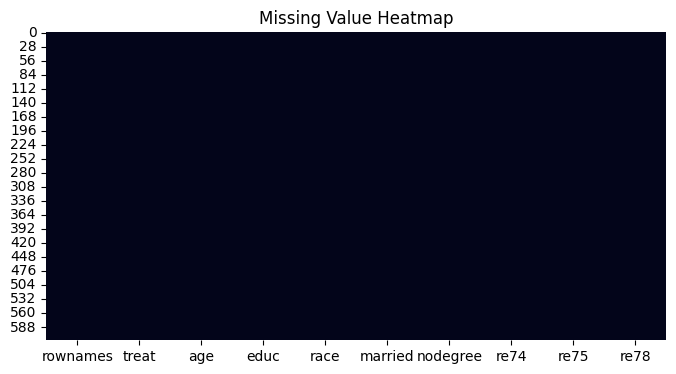

In [49]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

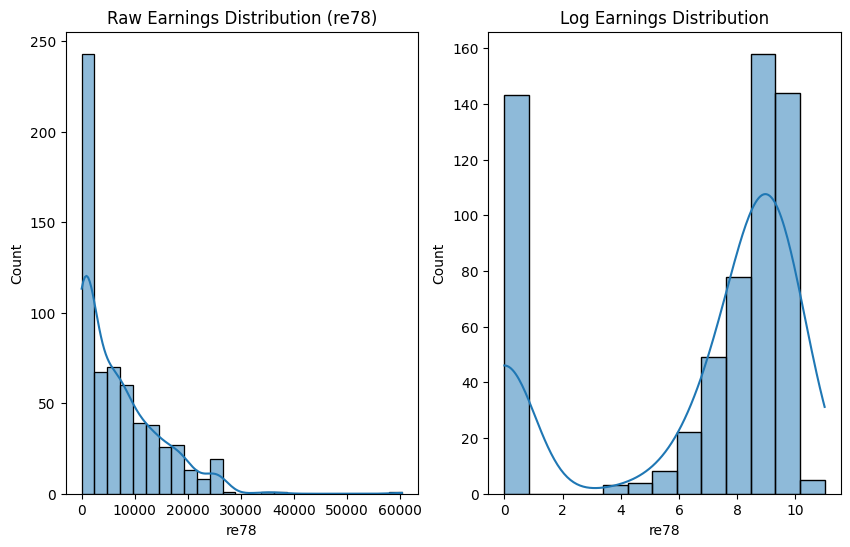

In [50]:
# Visualizing the Log-transformation
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['re78'], kde=True)
plt.title("Raw Earnings Distribution (re78)")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['re78'] + 1), kde=True)
plt.title("Log Earnings Distribution")

plt.show()

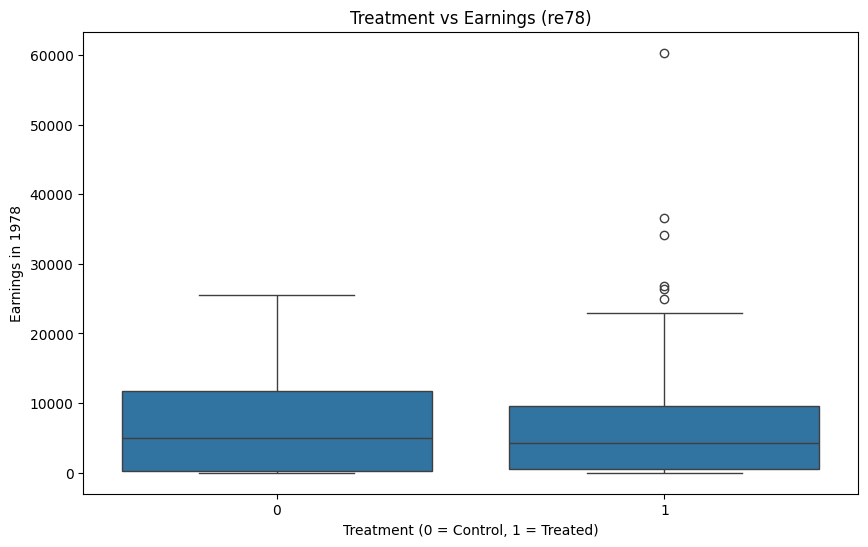

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(x='treat', y='re78', data=df)

plt.title("Treatment vs Earnings (re78)")
plt.xlabel("Treatment (0 = Control, 1 = Treated)")
plt.ylabel("Earnings in 1978")

plt.show()

In [52]:
# Manual Tukey Fence implementation

Q1 = df['re78'].quantile(0.25)
Q3 = df['re78'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['re78'] < (Q1 - 1.5 * IQR)) | (df['re78'] > (Q3 + 1.5 * IQR))]

In [53]:
print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 3


,rownames,treat,age,educ,race,married,nodegree,re74,re75,re78
106,NSW107,1,27,13,black,0,0,0.00,0.000,34099.28
131,NSW132,1,28,11,black,0,1,0.00,1284.079,60307.93
181,NSW182,1,25,14,black,1,0,35040.07,11536.570,36646.95
